In [23]:
from math import atan,cos,sin,pi,acos,exp
import numpy as np
from scipy import spatial
import random

import matplotlib.pyplot as pyplot 
import pickle

In [24]:
def get_angle_wrt_x_axis(pt1,pt2):
    ang = abs(atan((pt2[1]-pt1[1])/(pt2[0]-pt1[0])))
    
    if pt1[0]<pt2[0] and pt1[1]<pt2[1]: #1st quadrant
        return ang
    elif pt1[0]>pt2[0] and pt1[1]<pt2[1]: #2nd quadrant
        return pi-ang
    elif pt1[0]>pt2[0] and pt1[1]>pt2[1]: #3rd quadrant
        return pi+ang    
    elif pt1[0]<pt2[0] and pt1[1]>pt2[1]: #4th quadrant
        return 2*pi-ang

In [25]:
def forward_left(MN):
    theta_s = ((MN[2]-MN[3])*pi/2)+pi/2
    theta_e = ((MN[0]-MN[1])*pi/2)+pi/2
    # x = (L_s)*cos(theta_s)+L_e*cos(theta_s-theta_e) - 0.15
    # y = (L_s)*sin(theta_s)+L_e*sin(theta_s-theta_e)
    x = (L_s+L_e*cos(theta_e))*cos(theta_s) + L_e*sin(theta_e)*sin(theta_s) - 0.15
    y = (L_s+L_e*cos(theta_e))*sin(theta_s) - L_e*sin(theta_e)*cos(theta_s)
    
    return x,y

In [26]:
def forward_right(MN):
    theta_s = ((MN[2]-MN[3])*pi/2)+pi/2
    theta_e = ((MN[0]-MN[1])*pi/2)+pi/2
    x = (-L_s-L_e*cos(theta_e))*cos(theta_s) - L_e*sin(theta_e)*sin(theta_s) + 0.15
    y = -(-L_s-L_e*cos(theta_e))*sin(theta_s) - L_e*sin(theta_e)*cos(theta_s)
    # x = -(L_s)*cos(theta_s)-L_e*cos(theta_s-theta_e) + 0.15
    # y = (L_s)*sin(theta_s)+L_e*sin(theta_s-theta_e)
    
    return x,y

In [27]:
def find_centre(x1,y1,x2,y2,r):
    xdiff = x1-x2
    ydiff = y1-y2
    s = x1**2 - x2**2 + y1**2 - y2**2
    Cy = (s/(2*ydiff)) - y1
    A = (1+((xdiff/ydiff)**2))
    B = -2*(((x1*ydiff)+(Cy*xdiff))/ydiff)
    C = x1**2 + Cy**2 - r**2
    cx_1 = (-B + np.sqrt(B**2 - 4*A*C))/(2*A)
    cx_2 = (-B - np.sqrt(B**2 - 4*A*C))/(2*A)
    cy_1 = (s/(2*ydiff)) - ((xdiff/ydiff)*cx_1)
    cy_2 = (s/(2*ydiff)) - ((xdiff/ydiff)*cx_2)

    return cx_1,cy_1,cx_2,cy_2

In [28]:
def get_x_y_components_spline(pt1,pt2,tang):
    th = get_angle_wrt_x_axis(pt1,pt2)
    ang = pi/2-th #doubt: why and is calculated, x_fac should be sin(ang) right?
    x_fac = cos(ang)*tang
    y_fac = sin(ang)*tang
    
    return x_fac,y_fac

In [29]:
def get_circle_params(pt1,pt2,tang):
    d = spatial.distance.euclidean(pt1,pt2)
    r = (((d**2)/(4*tang))+tang)/2
    c = find_centre(pt1[0],pt1[1],pt2[0],pt2[1],r)
    ang = acos((r-tang)/r)
    
    return c, r, 2*ang


In [30]:
# Load distance vs time
with open("time_vs_dist.txt",'rb') as fp:
    d_vs_t = pickle.load(fp)
    d_vs_t = np.array(d_vs_t)
    time_perc = d_vs_t[:,0]
    dist_perc = d_vs_t[:,1]

In [31]:
time_perc

array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100.])

In [32]:
dist_perc

array([  0.        ,   1.2128435 ,   2.18812709,   3.91657228,
         6.91384203,  11.9202922 ,  19.78161114,  31.00255189,
        45.01660027,  59.86876601,  73.10585786,  83.20183851,
        90.02495109,  94.26758241,  96.77045353,  98.201379  ,
        99.00481981,  99.45137011,  99.69815837,  99.83411989,
       100.        ])

In [33]:
# Initialize parameters
arm_left = [-0.15,0]    
arm_right = [0.15,0]
L_s = 0.3
L_e = 0.3
peak_velocity_def  = 0.03
distance_def = 0.6
curvature = 0.07

In [34]:
# Define targets
targets = []
X = list(np.linspace(-0.7,0.7,29))
Y = list(np.linspace(0.31,0.6,29))
for x in X:
    for y in Y:
        targets.append([x,y])

In [35]:
# Get deducible parameters 
# Home position
home_left = forward_left([0.8,0.2,0.8,0.2])
home_right = forward_right([0.8,0.2,0.8,0.2])

In [36]:
home_left, home_right

((-0.0927050983124842, 0.17633557568774197),
 (0.0927050983124842, 0.17633557568774197))

In [37]:
# Output array for all targets
output = []
isochrony = []
n = 0
for target in targets:
    if target[0]<0:
        move_flag = "L"
    else:
        move_flag = "R"
    
    if move_flag=="L":
        # Initialize angle and arc parameters
        dist = spatial.distance.euclidean(home_left,target) # Distance between home and target
        if spatial.distance.euclidean(arm_left,target)>0.57:
            continue # Not reachable
        perp_max = curvature*dist # Maximum perpendicular distance of splined trajectory
        cent,rad,theta = get_circle_params(home_left,target,perp_max)
        cent = cent[2:] # Consider corresponding center
        theta_ch = get_angle_wrt_x_axis(cent,home_left) # Angle of center and home
        theta_ct = get_angle_wrt_x_axis(cent,target) # Angle of center and target
        
        # Initialize end effectors array
        # end_effectors = [np.array([home_left[0],home_left[1],home_right[0],home_right[1]])] # Starting movement from home position
        end_effectors = []
        for d in dist_perc:       
            theta_cov = d/100*theta
            if target[1]<home_left[1]:
                x_t = rad*cos(theta_ch-theta_cov)+cent[0] # Get x coordinate of resulting position
                y_t = rad*sin(theta_ch-theta_cov)+cent[1] # Get y coordinate of resulting position
            else:
                x_t = rad*cos(theta_ch+theta_cov)+cent[0] # Get x coordinate of resulting position
                y_t = rad*sin(theta_ch+theta_cov)+cent[1] # Get y coordinate of resulting position
            end_effectors.append(np.array([x_t,y_t,home_right[0],home_right[1]])) # Save to array           
        # end_effectors.append(np.array([target[0],target[1],home_right[0],home_right[1]])) # End movement with target location
        end_effectors = np.array(end_effectors)
        
    if move_flag=="R":
        # Initialize angle and arc parameters
        dist = spatial.distance.euclidean(home_right,target) # Distance between home and target
        if spatial.distance.euclidean(arm_right,target)>0.57:
            continue # Not reachable
        perp_max = curvature*dist # Maximum perpendicular distance of splined trajectory
        cent,rad,theta = get_circle_params(home_right,target,perp_max)        
        cent = cent[:2] # Consider corresponding center
        theta_ch = get_angle_wrt_x_axis(cent,home_right) # Angle of center and home
        theta_ct = get_angle_wrt_x_axis(cent,target) # Angle of center and target

        # Initialize end effectors array
        end_effectors = []
        for d in dist_perc:       
            theta_cov = d/100*theta
            if target[1]<home_right[1]:
                x_t = rad*cos(theta_ch+theta_cov)+cent[0] # Get x coordinate of resulting position
                y_t = rad*sin(theta_ch+theta_cov)+cent[1] # Get y coordinate of resulting position
            else:
                x_t = rad*cos(theta_ch-theta_cov)+cent[0] # Get x coordinate of resulting position
                y_t = rad*sin(theta_ch-theta_cov)+cent[1] # Get y coordinate of resulting position
            end_effectors.append(np.array([home_left[0],home_left[1],x_t,y_t]))
        # end_effectors.append(np.array([home_left[0],home_left[1],target[0],target[1]])) # End movement with target location
        end_effectors = np.array(end_effectors)  
    
    output.append(end_effectors)

with open("splined_trajectories_3.txt", "wb") as fp:   #Pickling
    pickle.dump(output, fp)

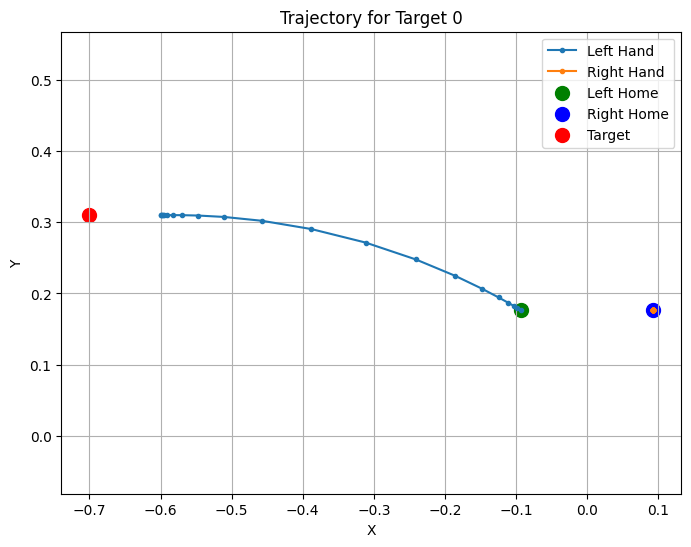

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Example: plotting the trajectory of a particular target
trajectory_index = 0  # choose which trajectory to plot
traj = np.array(output[trajectory_index])

# Extract coordinates
xL, yL, xR, yR = traj[:, 0], traj[:, 1], traj[:, 2], traj[:, 3]

# Plot the left and right hand trajectories
plt.figure(figsize=(8, 6))
plt.plot(xL, yL, '-o', label='Left Hand', markersize=3)
plt.plot(xR, yR, '-o', label='Right Hand', markersize=3)

# Plot start positions (home positions)
plt.scatter(home_left[0], home_left[1], color='green', s=100, label='Left Home')
plt.scatter(home_right[0], home_right[1], color='blue', s=100, label='Right Home')

# Plot target position
target = targets[trajectory_index]
plt.scatter(target[0], target[1], color='red', s=100, label='Target')

plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Trajectory for Target {trajectory_index}')
plt.legend()
plt.grid(True)
plt.axis('equal')  # maintain aspect ratio
plt.show()


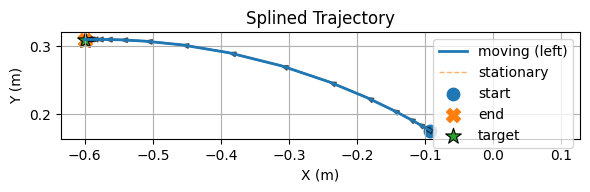

In [39]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin, pi
from scipy import spatial

# --- recreate minimal functions & params to get home positions ---
L_s = 0.3
L_e = 0.3
def forward_left(MN):
    theta_s = ((MN[2]-MN[3])*pi/2)+pi/2
    theta_e = ((MN[0]-MN[1])*pi/2)+pi/2
    x = (L_s+L_e*cos(theta_e))*cos(theta_s) + L_e*sin(theta_e)*sin(theta_s) - 0.15
    y = (L_s+L_e*cos(theta_e))*sin(theta_s) - L_e*sin(theta_e)*cos(theta_s)
    return x,y
def forward_right(MN):
    theta_s = ((MN[2]-MN[3])*pi/2)+pi/2
    theta_e = ((MN[0]-MN[1])*pi/2)+pi/2
    x = (-L_s-L_e*cos(theta_e))*cos(theta_s) - L_e*sin(theta_e)*sin(theta_s) + 0.15
    y = -(-L_s-L_e*cos(theta_e))*sin(theta_s) - L_e*sin(theta_e)*cos(theta_s)
    return x,y

arm_left = [-0.15,0]
arm_right = [0.15,0]
home_left = forward_left([0.8,0.2,0.8,0.2])
home_right = forward_right([0.8,0.2,0.8,0.2])

# --- reconstruct targets (same ordering as generation) ---
X = list(np.linspace(-0.7,0.7,29))
Y = list(np.linspace(0.31,0.6,29))
targets = [[x,y] for x in X for y in Y]

# --- load saved trajectories ---
with open("splined_trajectories_3.txt","rb") as fp:
    all_trajs = pickle.load(fp)

# --- find the first trajectory whose target was reachable (same skip logic used during generation) ---
saved_idx = 0
found = False
for tgt in targets:
    if tgt[0] < 0:  # left move
        if spatial.distance.euclidean(arm_left, tgt) > 0.57:
            continue
        traj = np.asarray(all_trajs[saved_idx])
        saved_idx += 1
        moving_xy = traj[:, :2]
        stationary_xy = traj[:, 2:4]
        found = True
        move_label = "left"
        break
    else:  # right move
        if spatial.distance.euclidean(arm_right, tgt) > 0.57:
            continue
        traj = np.asarray(all_trajs[saved_idx])
        saved_idx += 1
        moving_xy = traj[:, 2:4]
        stationary_xy = traj[:, :2]
        found = True
        move_label = "right"
        break

if not found:
    raise SystemExit("No reachable trajectory found in the saved file.")

# --- plotting ---
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(moving_xy[:,0], moving_xy[:,1], linewidth=2, label=f"moving ({move_label})")
ax.plot(stationary_xy[:,0], stationary_xy[:,1], linestyle="--", linewidth=1, alpha=0.6, label="stationary")
ax.scatter(moving_xy[0,0], moving_xy[0,1], marker="o", s=80, label="start")
ax.scatter(moving_xy[-1,0], moving_xy[-1,1], marker="X", s=100, label="end")
ax.scatter(tgt[0], tgt[1], marker="*", s=140, edgecolor='k', linewidth=0.8, label="target")
for i in range(0, len(moving_xy)-1, max(1, len(moving_xy)//12)):
    x0,y0 = moving_xy[i]; x1,y1 = moving_xy[min(i+1,len(moving_xy)-1)]
    ax.arrow(x0,y0,x1-x0,y1-y0, head_width=0.007, head_length=0.01, length_includes_head=True, alpha=0.6)
ax.set_aspect("equal", "box")
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_title("Splined Trajectory")
ax.grid(True); ax.legend(); plt.tight_layout(); plt.show()


In [40]:
len(output)

498